# Fundamentals of Software Systems (FSS)
**Software Evolution – Part 02 Assignment**

## Submission Guidelines

To correctly complete this assignment you must:

* Carry out the assignment in a team of 2 to 4 students.
* Carry out the assignment with your team only. You are allowed to discuss solutions with other teams, but each team should come up its own personal solution. A strict plagiarism policy is going to be applied to all the artifacts submitted for evaluation.
* As your submission, upload the filled Jupyter Notebook (including outputs) together with the d3 visualization web pages (i.e. upload everything you downloaded including the filled Jupyter Notebook plus your `output.json`)
* The files must be uploaded to OLAT as a single ZIP (`.zip`) file by 2024-12-02 18:00.


## Group Members
Francesco Manzionna - 23-745-979
Elena Battiston - 23-754-310
Daniel Tran - 24-741-753

## Task Context

In this assigment we will be analyzing the _[Nautilus trader](https://nautilustrader.io/)_ project. The git repository is available here: https://github.com/nautechsystems/nautilus_trader 

All following tasks should be done with the subset of commits from tag `v1.165.0` to tag `v1.206.0`.

In [1]:
import os
import json
import logging
import pandas as pd
import matplotlib.pyplot as plt
from git import Repo
from pathlib import PurePath
from datetime import datetime
from tqdm import tqdm

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


In [2]:
# Initialize the repository and define tags
repo_url = 'https://github.com/nautechsystems/nautilus_trader.git'
repo_path = './nautilus_trader'

# Clone the repository if not already cloned
if not os.path.exists(repo_path):
    print('Cloning repository...')
    Repo.clone_from(repo_url, repo_path)
else:
    print('Repository already cloned.')

# Initialize the Repo object
repo = Repo(repo_path)

# Define the tags
start_tag = 'v1.165.0'
end_tag = 'v1.206.0'

# Get commit objects for the tags
start_commit = repo.tags[start_tag].commit
end_commit = repo.tags[end_tag].commit

print(f'Start commit SHA: {start_commit.hexsha}')
print(f'End commit SHA: {end_commit.hexsha}')

commits = list(repo.iter_commits(f'{start_tag}..{end_tag}'))
print(f'Number of commits between {start_tag} and {end_tag}: {len(commits)}')


Repository already cloned.
Start commit SHA: d54c97abec8d02fbd8abfd930d9922e00dc6cb8f
End commit SHA: 00e23b664505799055279d398dff35d3b9904f0f
Number of commits between v1.165.0 and v1.206.0: 5114


In [3]:
# Define file extensions and subsystems
file_extensions = ['.py', '.pyx', '.pxd', '.rs']

# Define subsystems (directories inside nautilus_trader)
nautilus_trader_path = os.path.join(repo_path, 'nautilus_trader')
subsystems = ['nautilus_core']
subsystems += [d for d in os.listdir(nautilus_trader_path) if os.path.isdir(os.path.join(nautilus_trader_path, d))]
print('Subsystems:', subsystems)


Subsystems: ['nautilus_core', 'accounting', 'adapters', 'analysis', 'backtest', 'cache', 'common', 'config', 'core', 'data', 'examples', 'execution', 'indicators', 'live', 'model', 'persistence', 'portfolio', 'risk', 'serialization', 'system', 'test_kit', 'trading']


In [4]:
# Process commits once and collect data for all tasks

# Initialize data structures
task1_data = []  # For Task 1
task2_data = []  # For Task 2
task3_data = []  # For Task 3

logging.info("Starting to process commits...")

for commit in tqdm(commits, desc="Processing commits", unit="commit"):
    # For Task 3: collect per-commit code churn data
    stats = commit.stats.total
    date = datetime.fromtimestamp(commit.committed_date).date()
    task3_data.append({
        'date': date,
        'lines_added': stats['insertions'],
        'lines_deleted': stats['deletions'],
        'net_change': stats['lines'],
        'commit_hash': commit.hexsha
    })

    # For Task 1 and Task 2: process per-file stats
    author_name = commit.author.name
    author_email = commit.author.email
    if author_email is None:
        continue  # Skip commits without author email

    commit_hexsha = commit.hexsha

    for file_path, file_stats in commit.stats.files.items():
        _, ext = os.path.splitext(file_path)
        if ext in file_extensions:
            # Determine subsystem for Task 1
            if file_path.startswith('nautilus_core/'):
                subsystem = 'nautilus_core'
            elif file_path.startswith('nautilus_trader/'):
                parts = file_path.split('/')
                if len(parts) >= 2 and parts[1] in subsystems:
                    subsystem = parts[1]
                else:
                    subsystem = 'other'
            else:
                subsystem = 'other'

            # Lines added and deleted from file_stats
            lines_added = file_stats['insertions']
            lines_deleted = file_stats['deletions']
            net_lines_changed = lines_added + lines_deleted

            # Collect data for Task 1
            task1_data.append({
                'author': author_name,
                'subsystem': subsystem,
                'file_path': file_path,
                'commit_sha': commit_hexsha,
                'lines_added': lines_added,
                'lines_deleted': lines_deleted,
            })

            # Collect data for Task 2
            task2_data.append({
                'author': author_email,
                'file_path': file_path,
                'commit_sha': commit_hexsha,
                'lines_added': lines_added,
                'lines_deleted': lines_deleted,
                'net_lines_changed': net_lines_changed,
            })

logging.info("Processing complete. Total commits processed: %d", len(commits))
logging.info("Total data collected for Task 1: %d entries", len(task1_data))
logging.info("Total data collected for Task 2: %d entries", len(task2_data))
logging.info("Total data collected for Task 3: %d entries", len(task3_data))


2024-12-02 00:56:40,921 - INFO - Starting to process commits...
Processing commits: 100%|██████████| 5114/5114 [11:31<00:00,  7.40commit/s]
2024-12-02 01:08:12,208 - INFO - Processing complete. Total commits processed: 5114
2024-12-02 01:08:12,212 - INFO - Total data collected for Task 1: 26741 entries
2024-12-02 01:08:12,214 - INFO - Total data collected for Task 2: 26741 entries
2024-12-02 01:08:12,216 - INFO - Total data collected for Task 3: 5114 entries


## Task 1: Author contributions

In the following, please consider only Rust, Python, and Cython (pyx and pxd) files.

The first task is to get an overview of the author ownership of the Nautilus Trader project. In particular, we want to understand who are the main authors in the system between the two considered tags and what is the amount of their contributions both in absolute terms and in percentages. We also want to investigate if the same patterns apply on the various subsystems.

To this end, you should:
* extract all the contributions between the two tags. If an author committed a file 3 times, then the number of contributions of that author on that file is 3
* sort the authors by total number of contributions, define a threshold and from now on consider only the authors above the threshold
* consider the following subsystems: nautilus_core and all the directories inside nautilus_trader (e.g., accounting, adapters, analysis, ...)
* for the considered authors and the considered subsystems, create a matrix (for example a pandas dataframe) where the columns are the authors, the rows the subsystems, and the value of a cell is the number of contribution of that author on that subsystem
* now comment on the results: is the main author predominant in terms of contributions? how are the contributions distributed among the authors? are the subsystems similar in terms of distribution? To answer these questions compute an additional column that measure the percentage of contributions of the main author with respect to the total.
* redo all the previous steps but instead of counting the number of contributions, for every file in every commit, count the number of lines added. Produce a matrix equivalent to the previous one, using the lines added and comment on the results. Are the results the same if we look at the lines added instead of the number of contributions? For which subsystems are the results different?



In [5]:
df_task1 = pd.DataFrame(task1_data)
df_task1.head()


,author,subsystem,file_path,commit_sha,lines_added,lines_deleted
0,Chris Sellers,nautilus_core,nautilus_core/adapters/src/tardis/http/parse.rs,d79fd81bbb7bbfb53249f53e397f1b6e13bc9bc9,1,1
1,Chris Sellers,nautilus_core,nautilus_core/adapters/src/tardis/machine/clie...,d79fd81bbb7bbfb53249f53e397f1b6e13bc9bc9,1,1
2,Chris Sellers,nautilus_core,nautilus_core/adapters/src/tardis/machine/type...,d79fd81bbb7bbfb53249f53e397f1b6e13bc9bc9,2,1
3,Chris Sellers,nautilus_core,nautilus_core/adapters/src/tardis/python/confi...,d79fd81bbb7bbfb53249f53e397f1b6e13bc9bc9,3,3
4,Chris Sellers,nautilus_core,nautilus_core/data/src/engine/tests.rs,d79fd81bbb7bbfb53249f53e397f1b6e13bc9bc9,6,6


Analysis

Count Number of Contributions

In [6]:
# Contributions per author per subsystem
contrib_counts = df_task1.groupby(['author', 'subsystem']).size().reset_index(name='num_contributions')
contrib_counts.head()


,author,subsystem,num_contributions
0,Anurag Roy,adapters,1
1,Anurag Roy,nautilus_core,2
2,Ayush,nautilus_core,11
3,Ayush,other,3
4,Ayush Singh Bhandari,nautilus_core,10


In [7]:
# Compute total contributions per author
total_contributions = df_task1.groupby('author').size().reset_index(name='total_contributions')

# Identify main author
main_author = total_contributions.iloc[0]['author']
print('Main author:', main_author)

# Define threshold
threshold = total_contributions['total_contributions'].quantile(0.75)  # Top 25%
active_authors = total_contributions[total_contributions['total_contributions'] >= threshold]['author'].tolist()

# Ensure main_author is included in active_authors
if main_author not in active_authors:
    active_authors.append(main_author)

print('Active authors:', active_authors)


Main author: Anurag Roy
Active authors: ['Brad', 'Bradley McElroy', 'Chris Sellers', 'David Blom', 'Filip Macek', 'Ishan Bhanuka', 'Pushkar Mishra', 'faysou', 'rsmb7z', 'Anurag Roy']


In [8]:
# Filter the contributions to include only active authors
filtered_contrib_counts = contrib_counts[contrib_counts['author'].isin(active_authors)]


In [9]:
contrib_matrix = filtered_contrib_counts.pivot(index='subsystem', columns='author', values='num_contributions').fillna(0)
contrib_matrix


author,Anurag Roy,Brad,Bradley McElroy,Chris Sellers,David Blom,Filip Macek,Ishan Bhanuka,Pushkar Mishra,faysou,rsmb7z
subsystem,,,,,,,,,,
accounting,0.0,6.0,1.0,143.0,0.0,5.0,5.0,0.0,0.0,0.0
adapters,1.0,112.0,33.0,2638.0,162.0,69.0,33.0,0.0,7.0,72.0
analysis,0.0,0.0,0.0,91.0,0.0,0.0,3.0,0.0,0.0,0.0
backtest,0.0,9.0,13.0,525.0,4.0,2.0,11.0,0.0,4.0,10.0
cache,0.0,0.0,0.0,244.0,0.0,20.0,1.0,0.0,1.0,2.0
common,0.0,0.0,5.0,542.0,5.0,2.0,21.0,0.0,13.0,3.0
config,0.0,3.0,4.0,173.0,0.0,0.0,3.0,0.0,0.0,4.0
core,0.0,1.0,1.0,396.0,0.0,0.0,18.0,0.0,9.0,1.0
data,0.0,1.0,6.0,225.0,5.0,2.0,1.0,0.0,22.0,1.0


In [10]:
# Compute percentages
contrib_matrix['total_contributions'] = contrib_matrix.sum(axis=1)
contrib_matrix['main_author_percentage'] = (contrib_matrix[main_author] / contrib_matrix['total_contributions']) * 100
contrib_matrix


author,Anurag Roy,Brad,Bradley McElroy,Chris Sellers,David Blom,Filip Macek,Ishan Bhanuka,Pushkar Mishra,faysou,rsmb7z,total_contributions,main_author_percentage
subsystem,,,,,,,,,,,,
accounting,0.0,6.0,1.0,143.0,0.0,5.0,5.0,0.0,0.0,0.0,160.0,0.000000
adapters,1.0,112.0,33.0,2638.0,162.0,69.0,33.0,0.0,7.0,72.0,3127.0,0.031980
analysis,0.0,0.0,0.0,91.0,0.0,0.0,3.0,0.0,0.0,0.0,94.0,0.000000
backtest,0.0,9.0,13.0,525.0,4.0,2.0,11.0,0.0,4.0,10.0,578.0,0.000000
cache,0.0,0.0,0.0,244.0,0.0,20.0,1.0,0.0,1.0,2.0,268.0,0.000000
common,0.0,0.0,5.0,542.0,5.0,2.0,21.0,0.0,13.0,3.0,591.0,0.000000
config,0.0,3.0,4.0,173.0,0.0,0.0,3.0,0.0,0.0,4.0,187.0,0.000000
core,0.0,1.0,1.0,396.0,0.0,0.0,18.0,0.0,9.0,1.0,426.0,0.000000
data,0.0,1.0,6.0,225.0,5.0,2.0,1.0,0.0,22.0,1.0,263.0,0.000000


Lines Added Analysis

Sum Lines Added per Author per Subsystem

In [11]:
lines_added_counts = df_task1.groupby(['author', 'subsystem'])['lines_added'].sum().reset_index(name='lines_added')
lines_added_counts.head()


,author,subsystem,lines_added
0,Anurag Roy,adapters,39
1,Anurag Roy,nautilus_core,30
2,Ayush,nautilus_core,1137
3,Ayush,other,407
4,Ayush Singh Bhandari,nautilus_core,799


In [12]:
filtered_lines_added_counts = lines_added_counts[lines_added_counts['author'].isin(active_authors)]
lines_added_matrix = filtered_lines_added_counts.pivot(index='subsystem', columns='author', values='lines_added').fillna(0)
lines_added_matrix


author,Anurag Roy,Brad,Bradley McElroy,Chris Sellers,David Blom,Filip Macek,Ishan Bhanuka,Pushkar Mishra,faysou,rsmb7z
subsystem,,,,,,,,,,
accounting,0.0,76.0,1.0,706.0,0.0,88.0,74.0,0.0,0.0,0.0
adapters,39.0,2424.0,628.0,44109.0,8407.0,5319.0,259.0,0.0,391.0,6295.0
analysis,0.0,0.0,0.0,287.0,0.0,0.0,10.0,0.0,0.0,0.0
backtest,0.0,86.0,84.0,5307.0,33.0,5.0,166.0,0.0,58.0,175.0
cache,0.0,0.0,0.0,4164.0,0.0,645.0,5.0,0.0,2.0,71.0
common,0.0,0.0,80.0,11830.0,30.0,21.0,204.0,0.0,315.0,38.0
config,0.0,63.0,13.0,1520.0,0.0,0.0,65.0,0.0,0.0,37.0
core,0.0,2.0,8.0,5808.0,0.0,0.0,179.0,0.0,165.0,11.0
data,0.0,1.0,96.0,2756.0,122.0,24.0,21.0,0.0,694.0,3.0


In [13]:
lines_added_matrix['total_lines_added'] = lines_added_matrix.sum(axis=1)
lines_added_matrix['main_author_percentage'] = (lines_added_matrix[main_author] / lines_added_matrix['total_lines_added']) * 100
lines_added_matrix


author,Anurag Roy,Brad,Bradley McElroy,Chris Sellers,David Blom,Filip Macek,Ishan Bhanuka,Pushkar Mishra,faysou,rsmb7z,total_lines_added,main_author_percentage
subsystem,,,,,,,,,,,,
accounting,0.0,76.0,1.0,706.0,0.0,88.0,74.0,0.0,0.0,0.0,945.0,0.000000
adapters,39.0,2424.0,628.0,44109.0,8407.0,5319.0,259.0,0.0,391.0,6295.0,67871.0,0.057462
analysis,0.0,0.0,0.0,287.0,0.0,0.0,10.0,0.0,0.0,0.0,297.0,0.000000
backtest,0.0,86.0,84.0,5307.0,33.0,5.0,166.0,0.0,58.0,175.0,5914.0,0.000000
cache,0.0,0.0,0.0,4164.0,0.0,645.0,5.0,0.0,2.0,71.0,4887.0,0.000000
common,0.0,0.0,80.0,11830.0,30.0,21.0,204.0,0.0,315.0,38.0,12518.0,0.000000
config,0.0,63.0,13.0,1520.0,0.0,0.0,65.0,0.0,0.0,37.0,1698.0,0.000000
core,0.0,2.0,8.0,5808.0,0.0,0.0,179.0,0.0,165.0,11.0,6173.0,0.000000
data,0.0,1.0,96.0,2756.0,122.0,24.0,21.0,0.0,694.0,3.0,3717.0,0.000000


## Task 2: Knowledge loss

We now want to analyze the knowledge loss when the main contributor of the analyzed project would leave. For this we will use the circle packaging layout introduced in the "Code as a Crime Scene" book. This assignment includes the necessary `knowledge_loss.html` file as well as the `d3` folder for all dependencies. Your task is to create the `output.json` file according to the specification below. This file can then be visualized with the files provided.

For showing the visualization, once you have the output as `output.json` you should

* make sure to have the `knowledge_loss.html` file in the same folder
* start a local HTTP server in the same folder (e.g. with python `python3 -m http.server`) to serve the html file (necessary for d3 to work)
* open the served `knowledge_loss.html` and look at the visualization

Based on the visualization, comment on how is the project in terms of project loss and what could happen if the main contributor would leave.


### Output Format for Visualization

* `root` is always the root of the tree
* `size` should be the total number of lines of contribution
* `weight` can be set to the same as `size`
* `ownership` should be set to the percentage of contributions from the main author (e.g. 0.98 for 98% if contributions coming from the main author)

```
{
  "name": "root",
  "children": [
    {
      "name": "test",
      "children": [
        {
          "name": "benchmarking",
          "children": [
            {
              "author_color": "red",
              "size": "4005",
              "name": "t6726-patmat-analysis.scala",
              "weight": 1.0,
              "ownership": 0.9,
              "children": []
            },
            {
              "author_color": "red",
              "size": "55",
              "name": "TreeSetIterator.scala",
              "weight": 0.88,
              "ownership": 0.9,
              "children": []
            }
          ]
        }
      ]
    }
  ]
}
```

### JSON Export

For exporting the data to JSON you can use the following snippet:

```
import json

with open("output.json", "w") as file:
    json.dump(tree, file, indent=4)
```

In [14]:
# Create DataFrame from collected data and display first few rows
df_task2  = pd.DataFrame(task2_data)
logging.info('First few rows of the DataFrame:')
df_task2 .head()


2024-12-02 01:08:15,557 - INFO - First few rows of the DataFrame:


,author,file_path,commit_sha,lines_added,lines_deleted,net_lines_changed
0,chris@cjdsellers.io,nautilus_core/adapters/src/tardis/http/parse.rs,d79fd81bbb7bbfb53249f53e397f1b6e13bc9bc9,1,1,2
1,chris@cjdsellers.io,nautilus_core/adapters/src/tardis/machine/clie...,d79fd81bbb7bbfb53249f53e397f1b6e13bc9bc9,1,1,2
2,chris@cjdsellers.io,nautilus_core/adapters/src/tardis/machine/type...,d79fd81bbb7bbfb53249f53e397f1b6e13bc9bc9,2,1,3
3,chris@cjdsellers.io,nautilus_core/adapters/src/tardis/python/confi...,d79fd81bbb7bbfb53249f53e397f1b6e13bc9bc9,3,3,6
4,chris@cjdsellers.io,nautilus_core/data/src/engine/tests.rs,d79fd81bbb7bbfb53249f53e397f1b6e13bc9bc9,6,6,12


In [15]:
# Identify the main author based on total net lines changed
total_contributions = df_task2.groupby('author')['net_lines_changed'].sum().reset_index(name='total_net_lines_changed')
total_contributions = total_contributions.sort_values(by='total_net_lines_changed', ascending=False)

logging.info('Total contributions per author (using emails):')
for index, row in total_contributions.iterrows():
    logging.info(f"Author Email: {row['author']}, Total Net Lines Changed: {row['total_net_lines_changed']}")

main_author = total_contributions.iloc[0]['author']
logging.info(f'Main author identified: {main_author}')


2024-12-02 01:08:15,987 - INFO - Total contributions per author (using emails):
2024-12-02 01:08:15,989 - INFO - Author Email: chris@cjdsellers.io, Total Net Lines Changed: 775258
2024-12-02 01:08:15,992 - INFO - Author Email: filip_macek@hotmail.com, Total Net Lines Changed: 91242
2024-12-02 01:08:15,994 - INFO - Author Email: bhanuka.ishan@gmail.com, Total Net Lines Changed: 33442
2024-12-02 01:08:15,996 - INFO - Author Email: bradley.mcelroy@live.com, Total Net Lines Changed: 29314
2024-12-02 01:08:15,998 - INFO - Author Email: pushkarmishra029@gmail.com, Total Net Lines Changed: 19958
2024-12-02 01:08:15,999 - INFO - Author Email: 105105941+rsmb7z@users.noreply.github.com, Total Net Lines Changed: 19340
2024-12-02 01:08:16,000 - INFO - Author Email: reecek@uniciant.com, Total Net Lines Changed: 14920
2024-12-02 01:08:16,002 - INFO - Author Email: davidsblom@gmail.com, Total Net Lines Changed: 13184
2024-12-02 01:08:16,004 - INFO - Author Email: benjaminsingleton@users.noreply.githu

In [16]:
# Group data by file and author
author_file_lines = df_task2.groupby(['file_path', 'author'])['net_lines_changed'].sum().reset_index()
author_file_lines.head()


,file_path,author,net_lines_changed
0,build.py,bhanuka.ishan@gmail.com,134
1,build.py,chris@cjdsellers.io,708
2,build.py,georgehill010@gmail.com,8
3,docs/_pygments/monokai.py,chris@cjdsellers.io,33
4,docs/_pygments/monokai.py,pushkarmishra029@gmail.com,109


In [17]:
# Get the total number of lines in each file at end_tag
def get_files_in_tree(tree, path=''):
    files = []
    for item in tree:
        if item.type == 'blob':
            file_path = os.path.join(path, item.name)
            files.append((file_path, item))
        elif item.type == 'tree':
            files.extend(get_files_in_tree(item, os.path.join(path, item.name)))
    return files

end_tree = end_commit.tree
files_in_tree = get_files_in_tree(end_tree)

logging.info(f'Total number of files at {end_tag}: {len(files_in_tree)}')

2024-12-02 01:08:17,327 - INFO - Total number of files at v1.206.0: 2342


In [18]:
# Count lines in each file at end_tag
file_line_counts = {}
logging.info('Counting lines in each file at end_tag...')

for file_path, blob in files_in_tree:
    _, ext = os.path.splitext(file_path)
    if ext in file_extensions:
        try:
            data_blob = blob.data_stream.read()
            text = data_blob.decode('utf-8', errors='ignore')
            num_lines = len(text.splitlines())
            normalized_path = os.path.normpath(file_path)
            file_line_counts[normalized_path] = num_lines
        except Exception as e:
            logging.error(f"Error reading file {file_path}: {e}")

logging.info(f'Completed counting lines in files.')


2024-12-02 01:08:17,791 - INFO - Counting lines in each file at end_tag...
2024-12-02 01:08:18,237 - INFO - Completed counting lines in files.


In [19]:
# Prepare data for each file (size, weight, ownership, author_color)
files_data = []

logging.info('Preparing file data for the tree structure...')

# Calculate total net lines changed per file
total_lines_per_file = author_file_lines.groupby('file_path')['net_lines_changed'].sum().reset_index()
total_lines_per_file = total_lines_per_file.rename(columns={'net_lines_changed': 'total_net_lines_changed'})

# Merge total lines per file back into author_file_lines
author_file_lines = author_file_lines.merge(total_lines_per_file, on='file_path')

# Calculate ownership for each file per author
author_file_lines['ownership'] = author_file_lines['net_lines_changed'] / author_file_lines['total_net_lines_changed']

# Filter for main author
main_author_file_lines = author_file_lines[author_file_lines['author'] == main_author]

# Create a dictionary for quick lookup of main author's ownership per file
ownership_dict = dict(zip(main_author_file_lines['file_path'], main_author_file_lines['ownership']))

for file_path, num_lines in file_line_counts.items():
    # Get the main author's ownership for this file
    ownership = ownership_dict.get(file_path, 0)
    author_color = 'red' if ownership >= 0.5 else 'blue'

    files_data.append({
        'file_path': file_path,
        'size': num_lines,
        'weight': num_lines,
        'ownership': round(ownership, 2),  # Rounded for readability
        'author_color': author_color,
    })

logging.info('File data preparation complete.')


2024-12-02 01:08:18,408 - INFO - Preparing file data for the tree structure...
2024-12-02 01:08:18,455 - INFO - File data preparation complete.


In [20]:
# Build the directory tree structure using pathlib.PurePath
def build_tree(files_data):
    tree = {'name': 'root', 'children': []}
    for file_data in files_data:
        # Use pathlib.PurePath to handle paths
        path = PurePath(file_data['file_path'])
        path_parts = path.parts  # This will give a tuple of path components
        current_node = tree
        for part in path_parts[:-1]:
            # Find or create the child node
            found = False
            for child in current_node['children']:
                if child['name'] == part:
                    current_node = child
                    found = True
                    break
            if not found:
                new_node = {'name': part, 'children': []}
                current_node['children'].append(new_node)
                current_node = new_node
        # Add the file as a leaf node
        leaf_node = {
            'name': path_parts[-1],
            'size': file_data['size'],
            'weight': file_data['weight'],
            'ownership': file_data['ownership'],
            'author_color': file_data['author_color'],
            'children': []
        }
        current_node['children'].append(leaf_node)
    return tree

logging.info('Building the directory tree structure...')
tree = build_tree(files_data)
logging.info('Directory tree built successfully.')


2024-12-02 01:08:18,713 - INFO - Building the directory tree structure...
2024-12-02 01:08:18,739 - INFO - Directory tree built successfully.


In [21]:
# Export the tree to a JSON file
output_file = 'output.json'
with open(output_file, 'w') as file:
    json.dump(tree, file, indent=4)

logging.info(f'Tree structure exported to {output_file}.')


2024-12-02 01:08:19,057 - INFO - Tree structure exported to output.json.


In [33]:
from IPython.display import IFrame
# You need to have server running: `python3 -m http.server` || `py -m http.server`
IFrame(src='http://localhost:8000/knowledge_loss.html', width='100%', height=1000)


### Comment
Based on the visualization, the project appears to have a low risk of significant knowledge loss if the main contributor were to leave. Most files are colored blue with 0% ownership by the main contributor, indicating that the codebase has distributed contributions from multiple authors.

The `build.py` file stands out with an 84% ownership by the main contributor, colored red. This could potentially pose a risk if the contributor were to leave without transferring the knowledge. 

## Task 3: Code Churn Analysis

The third and last task is to analyze the code churn of the _Nautilus Trader_ project. For this analysis we look at the code churn, meaning the daily change in the total number of lines of the project.

Visualize the code churn over time bucketing the data by day. Remember that you'll need to consider also the days when there are no commits.

Look at the churn trend over time, identify one outlier of your choice, and for it:

* investigate if it was caused by a single or multiple commits (since you are bucketing the data by day)
* find the involved commit(s) and look at the commit message(s)
* find the involved files, and for each file look at the number of lines added and/or deleted as well as the modification type (addition, deletion, modification, renaming)

Based on the above, discuss the potential reasons for the outlier and if it should be a reason for concern.

In [23]:
# Create a DataFrame
churn_df = pd.DataFrame(task3_data)

# Aggregate churn by date
daily_churn = churn_df.groupby('date').agg({
    'lines_added': 'sum',
    'lines_deleted': 'sum',
    'net_change': 'sum'
}).reset_index()

In [24]:
start_date = daily_churn['date'].min()
end_date = daily_churn['date'].max()
all_dates = pd.date_range(start=start_date, end=end_date, freq='D')
daily_churn = daily_churn.set_index('date').reindex(all_dates, fill_value=0).rename_axis('date').reset_index()

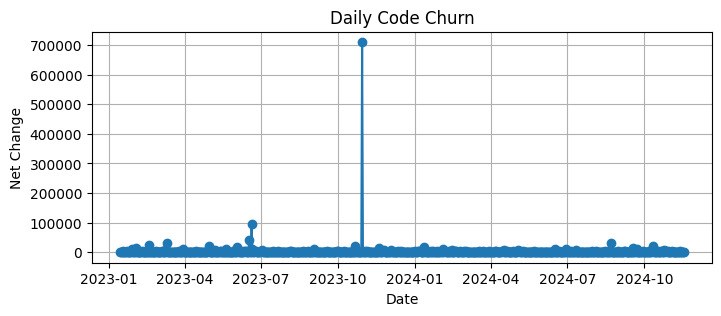

In [25]:
# Plotting the net change over time
plt.figure(figsize=(8, 3))
plt.plot(daily_churn['date'], daily_churn['net_change'], marker='o', linestyle='-')
plt.title('Daily Code Churn')
plt.xlabel('Date')
plt.ylabel('Net Change')
plt.grid(True)
plt.show()


In [26]:
outlier_index = daily_churn['net_change'].abs().idxmax()
outlier_date = daily_churn.loc[outlier_index, 'date']
outlier_value = daily_churn.loc[outlier_index, 'net_change']
outlier_date, outlier_value


(Timestamp('2023-10-30 00:00:00'), np.int64(709636))

In [27]:
# Ensure both outlier_date and commit dates are of the same type
outlier_date = pd.Timestamp(outlier_date).date()

outlier_commits = [
    commit for commit in commits
    if datetime.fromtimestamp(commit.committed_date).date() == outlier_date
]
len(outlier_commits)



17

In [28]:
for commit in outlier_commits:
    print(f"Commit Hash: {commit.hexsha}")
    print(f"Author: {commit.author.name}")
    print(f"Date: {datetime.fromtimestamp(commit.committed_date)}")
    print(f"Message:\n{commit.message}")
    print("-" * 80)


Commit Hash: ac35686d4a3cf2b68fddeb2922af627e4b1e1e05
Author: Chris Sellers
Date: 2023-10-30 12:38:13
Message:
Use call_soon_threadsafe for live engine queues

--------------------------------------------------------------------------------
Commit Hash: 463cc08dc197a3294a37769249c699a73c5fb77a
Author: Chris Sellers
Date: 2023-10-30 11:34:50
Message:
Cleanup build

--------------------------------------------------------------------------------
Commit Hash: 5bd2ef017b2240d12c95be6534e26d80c64b516f
Author: Chris Sellers
Date: 2023-10-30 09:17:28
Message:
Relax typing for BinanceSpotSymbolInfo.permissions

--------------------------------------------------------------------------------
Commit Hash: 6d5388713fa59f100d67a303673474b3d3254eff
Author: Chris Sellers
Date: 2023-10-30 08:50:01
Message:
Update DatabentoInstrumentProvider

--------------------------------------------------------------------------------
Commit Hash: 33631a5c1257772c43a5d32fc666be03145fda95
Author: Chris Sellers
Date

In [29]:
for commit in outlier_commits:
    print(f"Analyzing Commit: {commit.hexsha}")
    for file, stats in commit.stats.files.items():
        print(f"File: {file}")
        print(f"Lines Added: {stats['insertions']}, Lines Deleted: {stats['deletions']}")
        # Determine modification type
        if stats['insertions'] > 0 and stats['deletions'] == 0:
            mod_type = 'Addition'
        elif stats['insertions'] == 0 and stats['deletions'] > 0:
            mod_type = 'Deletion'
        elif stats['insertions'] > 0 and stats['deletions'] > 0:
            mod_type = 'Modification'
        else:
            mod_type = 'Unchanged'
        print(f"Modification Type: {mod_type}")
        print("-" * 40)
    print("=" * 80)


Analyzing Commit: ac35686d4a3cf2b68fddeb2922af627e4b1e1e05
File: nautilus_trader/live/data_engine.py
Lines Added: 8, Lines Deleted: 8
Modification Type: Modification
----------------------------------------
File: nautilus_trader/live/execution_engine.py
Lines Added: 4, Lines Deleted: 4
Modification Type: Modification
----------------------------------------
File: nautilus_trader/live/risk_engine.py
Lines Added: 4, Lines Deleted: 4
Modification Type: Modification
----------------------------------------
File: tests/unit_tests/live/test_execution_engine.py
Lines Added: 1, Lines Deleted: 2
Modification Type: Modification
----------------------------------------
Analyzing Commit: 463cc08dc197a3294a37769249c699a73c5fb77a
File: build.py
Lines Added: 0, Lines Deleted: 10
Modification Type: Deletion
----------------------------------------
Analyzing Commit: 5bd2ef017b2240d12c95be6534e26d80c64b516f
File: RELEASES.md
Lines Added: 1, Lines Deleted: 0
Modification Type: Addition
------------------

In [30]:
for commit in outlier_commits:
    print(f"Analyzing Commit: {commit.hexsha}")
    for file, stats in commit.stats.files.items():
        print(f"File: {file}")
        print(f"Lines Added: {stats['insertions']}, Lines Deleted: {stats['deletions']}")
        if stats['insertions'] > 0 and stats['deletions'] == 0:
            mod_type = 'Addition'
        elif stats['insertions'] == 0 and stats['deletions'] > 0:
            mod_type = 'Deletion'
        elif stats['insertions'] > 0 and stats['deletions'] > 0:
            mod_type = 'Modification'
        else:
            mod_type = 'Unchanged'
        print(f"Modification Type: {mod_type}")
        print("-" * 40)
    print("=" * 80)

Analyzing Commit: ac35686d4a3cf2b68fddeb2922af627e4b1e1e05
File: nautilus_trader/live/data_engine.py
Lines Added: 8, Lines Deleted: 8
Modification Type: Modification
----------------------------------------
File: nautilus_trader/live/execution_engine.py
Lines Added: 4, Lines Deleted: 4
Modification Type: Modification
----------------------------------------
File: nautilus_trader/live/risk_engine.py
Lines Added: 4, Lines Deleted: 4
Modification Type: Modification
----------------------------------------
File: tests/unit_tests/live/test_execution_engine.py
Lines Added: 1, Lines Deleted: 2
Modification Type: Modification
----------------------------------------
Analyzing Commit: 463cc08dc197a3294a37769249c699a73c5fb77a
File: build.py
Lines Added: 0, Lines Deleted: 10
Modification Type: Deletion
----------------------------------------
Analyzing Commit: 5bd2ef017b2240d12c95be6534e26d80c64b516f
File: RELEASES.md
Lines Added: 1, Lines Deleted: 0
Modification Type: Addition
------------------

In [31]:
# Summarize churn at the file level
file_summary = []
for commit in outlier_commits:
    for file, stats in commit.stats.files.items():
        file_summary.append({
            'file': file,
            'lines_added': stats['insertions'],
            'lines_deleted': stats['deletions'],
            'net_change': stats['lines']
        })

file_summary_df = pd.DataFrame(file_summary)
file_summary_df = file_summary_df.groupby('file').sum().reset_index()

# Sort by net change
file_summary_df.sort_values(by='net_change', ascending=False)


,file,lines_added,lines_deleted,net_change
105,tests/test_data/truefx-audusd-ticks.csv,0,100001,100001
107,tests/test_data/truefx/audusd-ticks.csv,100001,0,100001
78,tests/test_data/binance/ethusdt-trades.csv,69807,0,69807
71,tests/test_data/binance-ethusdt-trades.csv,0,69807,69807
92,tests/test_data/ftx-btc-perp-20211231-20220201...,0,45032,45032
...,...,...,...,...
64,tests/test_data/bars_eurusd_2019_sim.parquet,0,0,0
70,tests/test_data/binance-btcusdt-trades.parquet,0,0,0
69,tests/test_data/binance-btcusdt-quotes.parquet,0,0,0
77,tests/test_data/binance/btcusdt-trades.parquet,0,0,0


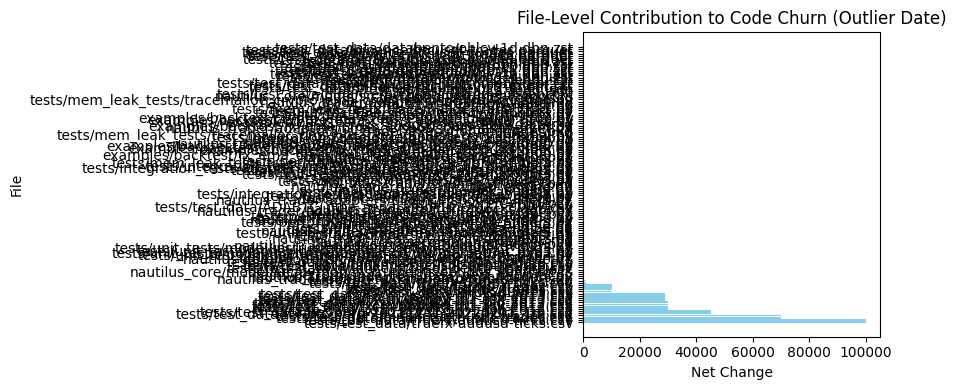

In [32]:
file_summary_df.sort_values(by='net_change', ascending=False, inplace=True)

plt.figure(figsize=(9, 4))
plt.barh(file_summary_df['file'], file_summary_df['net_change'], color='skyblue')
plt.title('File-Level Contribution to Code Churn (Outlier Date)')
plt.xlabel('Net Change')
plt.ylabel('File')
plt.tight_layout()
plt.show()


### Discussion outlier

The outlier, occurring on October 30, 2023, shows a significant spike in net code churn, exceeding 700,000 lines. This anomaly, identified as the largest change in the dataset, was caused by multiple commits made on the same day. These commits included substantial changes to test datasets, such as the addition and deletion of over 100,000 lines in `truefx-audusd-ticks.csv`. Smaller modifications were made to project files like `data_engine.py` and `risk_engine.py`, which indicate ongoing feature development and maintenance.

The large churn is likely due to routine updates, including the replacement or adjustment of large test files and maintenance of the codebase. Commit messages such as "Cleanup build" and "Relax typing" suggest this was planned work rather than unexpected issues. The choice of this outlier is justified by its scale and potential to highlight key patterns in project activity.

This outlier is not a concern as the changes appear intentional and necessary for project evolution. Large spikes in churn are expected in projects with periodic updates to datasets or significant refactoring. However, such events underscore the importance of clear commit practices and testing to maintain code stability.